## Nome: Pedro Henrique de Paiva Carvalho
## Mátricula: 2162


---

# Atividade 6 - Interpolação de Lagrange

### Função de interpolação de Lagrange

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def lagrange_base(xs, k, x):
    # xs: nós de interpolação (ex.: valores de irradiação conhecidos da tabela)
    # k : índice do nó atual (para construir L_k)
    # x : ponto ou pontos onde vamos avaliar L_k(x)

    xs = np.asarray(xs, dtype=float)  # garante que xs é array NumPy
    x = np.asarray(x, dtype=float)    # garante que x também pode ser array
    xk = xs[k]                        # valor do nó correspondente ao índice k
    L = np.ones_like(x, dtype=float)  # inicializa L(x) = 1 (vai acumular o produto)

    # Produto: L_k(x) = ∏ (x - xj) / (xk - xj), para j ≠ k
    for j, xj in enumerate(xs):
        if j == k:
            continue                  # não usamos o termo quando j = k
        L *= (x - xj) / (xk - xj)     # multiplica cada fator do produto

    return L                          # retorna o valor de L_k(x)


# Utilizar essa função que calcula o polinômio interpolador de Lagrange P_n(x)
def lagrange_interp(xs, ys, x):
    # xs: nós de interpolação (ex.: valores de irradiação conhecidos)
    # ys: valores da função nos nós (ex.: energias geradas conhecidas)
    # x : ponto(s) onde queremos calcular P_n(x)

    xs = np.asarray(xs, dtype=float)
    ys = np.asarray(ys, dtype=float)
    x = np.asarray(x, dtype=float)
    P = np.zeros_like(x, dtype=float)  # inicializa P(x) = 0

    # Soma: P_n(x) = Σ yk * L_k(x)
    for k in range(len(xs)):
        P += ys[k] * lagrange_base(xs, k, x)  # acumula cada termo da soma

    return P  # retorna o valor do polinômio em x

### Função para plotar os pontos e o polinômio interpolador

In [5]:


def plot_interpolacao(xs, ys, pontos_estimativa=None):
    """
    Plota o polinômio interpolador de Lagrange a partir dos dados fornecidos.

    Parâmetros:
    -----------
    xs : array-like
        Nós de interpolação (ex.: valores de tempo conhecidos).
    ys : array-like
        Valores da função nos nós (ex.: temperaturas medidas correspondentes).
    pontos_estimativa : lista ou array, opcional
        Pontos onde se deseja destacar as estimativas no gráfico (ex.: [10, 11]).
    """

    # Cria um eixo denso para desenhar o polinômio
    xx = np.linspace(min(xs), max(xs), 600)
    Pn = lagrange_interp(xs, ys, xx)

    plt.figure(figsize=(8,5))

    # Plota os pontos originais da tabela
    plt.scatter(xs, ys, label='Dados (tabela)', color='blue')

    # Plota o polinômio interpolador
    plt.plot(xx, Pn, linestyle='--', label='Polinômio interpolador P_n(x)', color='orange')

    # Se pontos de estimativa forem passados, calcula e marca no gráfico
    if pontos_estimativa is not None:
        pontos_estimativa = np.array(pontos_estimativa)
        valores_estimados = lagrange_interp(xs, ys, pontos_estimativa)
        plt.scatter(pontos_estimativa, valores_estimados, marker='x', s=80, color='red', label='Estimativas')

    # Rótulos e título
    plt.xlabel('Tempo (min)')
    plt.ylabel('Temperatura (°C)')
    plt.title('Interpolação de Lagrange — Tempo vs Temperatura')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()

### Parte Prática

Uma equipe de engenharia mecânica está caracterizando a curva de resfriamento de uma peça metálica recém-forjada, essencial para definir o processo de tratamento térmico. Sensores de temperatura foram posicionados na peça e registraram a temperatura em diferentes instantes de tempo após a saída do forno.

Os resultados das medições estão na tabela abaixo:

| Tempo (min) | Temperatura (°C) |
|--------------------|---------------|
| 0                 | 850         |
| 2                 | 620          |
| 4                 | 470          |
| 6                 | 360          |
| 8                 | 290          |
| 10                | 245          |

Com base nesses dados, responda:

1. Faça uma estimativa da temperatura da peça considerando os instantes de 1 min, 5 min, 7 min e 12 min. (Arredondar os resultados para duas casas decimais)

In [7]:
xs = [0, 2, 4, 6, 8, 10]
ys = [850, 620, 470, 360, 290, 245]
pontos_estimativa = [1, 5, 7, 12]

estimativas = lagrange_interp(xs, ys, pontos_estimativa)

for p, est in zip(pontos_estimativa, estimativas):
    print(f"Tempo: {p} min -> Temperatura estimada: {est:.2f} °C")


Tempo: 1 min -> Temperatura estimada: 719.43 °C
Tempo: 5 min -> Temperatura estimada: 410.29 °C
Tempo: 7 min -> Temperatura estimada: 319.94 °C
Tempo: 12 min -> Temperatura estimada: 140.00 °C


2. Plote um gráfico com os pontos conhecidos e o polinômio interpolador de Lagrange.

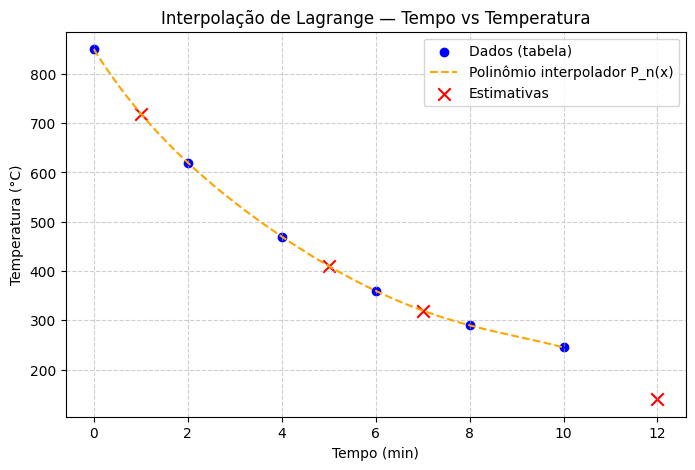

In [10]:
plot_interpolacao(xs, ys, pontos_estimativa)

### Parte Teórica

1. Qual é a diferença entre interpolar um conjunto de dados e extrapolar a partir dele? Por que a extrapolação costuma ser mais arriscada?

Resposta: A interpolação foca em encontrar resultados dentro de um intervalo definido de x, enquanto a extrapolação é fora do intervalo, apresentando um risco do polinômio divergir da realidade.

2. Se um novo ponto de medição fosse adicionado à tabela (por exemplo, a temperatura em 3 min), o polinômio de Lagrange calculado anteriormente mudaria? Justifique.

Resposta: Mudaria pois, o grau do polinômio de Lagrange depende da quantidade de pontos na tabela.

3. No contexto do resfriamento da peça metálica, o que aconteceria com o polinômio interpolador se dois dos pontos medidos tivessem exatamente o mesmo instante de tempo, mas temperaturas diferentes (por exemplo, devido a um erro de leitura do sensor)? Isso seria um problema para a interpolação de Lagrange?

Resposta: Isso faria com que o método fosse inviabilizado, pois, a formula de Li(x) usaria a subrtração do tempo no denominador, tempos iguais causariam uma divisão por zero.